# Analiza i zaključci

Ovaj notebook analizira rezultate eksperimenata (razliciti optimizatori, batch size i learning rate).

- Automatski ucitava sve dostupne `master_summary.csv` fajlove
- Sumira rezultate po optimizatoru, `batch` i `lr`

In [17]:
import os, glob, json, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [18]:
def load_all_summaries(root='runs'):
    pattern = os.path.join(root, '*', 'master_summary.csv')
    files = sorted(glob.glob(pattern))
    dfs = []
    for f in files:
        try:
            df = pd.read_csv(f)
        except Exception as e:
            print(f'Warning: cannot read {f}: {e}')
            continue
        if df.shape[0] == 0:
            continue
        df['summary_file'] = f
        dfs.append(df)
    if not dfs:
        return pd.DataFrame()
    out = pd.concat(dfs, ignore_index=True)
    return out

df = load_all_summaries('runs')
df_raw = df.copy()
print('Broj redova:', len(df))
display(df.head(3))

Broj redova: 27


,run_dir,model,optimizer,lr,batch,epochs,val_best_acc,test_acc,test_macro_f1,train_time_sec,status,error,summary_file
0,runs\20251029-024320\small_opt-momentum_lr-0.1...,small,momentum,0.10,32,10,0.916333,0.9131,0.912851,1147.992691,ok,NaN,runs\20251029-024320\master_summary.csv
1,runs\20251029-024320\small_opt-momentum_lr-0.0...,small,momentum,0.01,32,10,0.913667,0.9103,0.910054,1104.834240,ok,NaN,runs\20251029-024320\master_summary.csv
2,runs\20251029-024320\small_opt-momentum_lr-0.1...,small,momentum,0.10,64,10,0.914500,0.9103,0.909888,1015.197285,ok,NaN,runs\20251029-024320\master_summary.csv


In [19]:
if not df.empty:
    for col in ['lr','batch','epochs','val_best_acc','test_acc','test_macro_f1','train_time_sec']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    for col in ['model','optimizer','status','error','run_dir']:
        if col in df.columns:
            df[col] = df[col].astype(str)

    df['time_per_epoch'] = df['train_time_sec'] / df['epochs']

    df['model'] = df['model'].str.lower().str.strip()
    df['optimizer'] = df['optimizer'].str.lower().str.strip()

    optimizer_order = ['adam','nag','momentum','sgd', 'rmsprop']
    df['optimizer'] = pd.Categorical(df['optimizer'], categories=optimizer_order, ordered=True)

    display(df.describe(include='all'))
else:
    print('No data.')

,run_dir,model,optimizer,lr,batch,epochs,val_best_acc,test_acc,test_macro_f1,train_time_sec,status,error,summary_file,time_per_epoch
count,27,27,27,27.000000,27.000000,27.0,27.000000,27.000000,27.000000,27.000000,27,27,27,27.000000
unique,27,4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,5,NaN
top,runs\20251029-024320\small_opt-momentum_lr-0.1...,small,adam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ok,nan,runs\20251029-024320\master_summary.csv,NaN
freq,1,14,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27,27,23,NaN
mean,NaN,NaN,NaN,0.036574,45.037037,10.0,0.913981,0.910870,0.910330,1668.711148,NaN,NaN,NaN,166.871115
std,NaN,NaN,NaN,0.043717,16.022776,0.0,0.009012,0.010127,0.010093,822.299705,NaN,NaN,NaN,82.229970
min,NaN,NaN,NaN,0.000500,32.000000,10.0,0.890500,0.883000,0.883507,370.093222,NaN,NaN,NaN,37.009322
25%,NaN,NaN,NaN,0.001000,32.000000,10.0,0.913250,0.910000,0.909212,1110.079315,NaN,NaN,NaN,111.007931
50%,NaN,NaN,NaN,0.010000,32.000000,10.0,0.915000,0.913100,0.912851,1240.312217,NaN,NaN,NaN,124.031222
75%,NaN,NaN,NaN,0.100000,64.000000,10.0,0.919333,0.916150,0.915801,2459.109341,NaN,NaN,NaN,245.910934


In [22]:
if not df.empty:
    # Top overall by test_acc
    top_overall = df.sort_values('test_acc', ascending=False).head(5)
    print('Top 5 (po test_acc):')
    display(top_overall[['model','optimizer','lr','batch','epochs','val_best_acc','test_acc','test_macro_f1','time_per_epoch','run_dir']])
    # Top per model
    def top_k_per_group(dd, key='test_acc', k=5):
        return dd.sort_values(key, ascending=False).head(k)
    tops = df.groupby('model', as_index=False).apply(lambda g: top_k_per_group(g, 'test_acc', 2))
    print('Top 2 po modelu (po test_acc):')
    display(tops[['model','optimizer','lr','batch','epochs','val_best_acc','test_acc','test_macro_f1','time_per_epoch','run_dir']])
else:
    print('No data.')

Top 5 (po test_acc):


,model,optimizer,lr,batch,epochs,val_best_acc,test_acc,test_macro_f1,time_per_epoch,run_dir
16,medium,momentum,0.100,64,10,0.924333,0.9223,0.921278,297.808526,runs\20251029-024320\medium_opt-momentum_lr-0....
20,medium,nag,0.100,64,10,0.925000,0.9218,0.921005,298.798114,runs\20251029-024320\medium_opt-nag_lr-0.1_bs-...
18,medium,nag,0.100,32,10,0.922167,0.9199,0.919001,260.300753,runs\20251029-024320\medium_opt-nag_lr-0.1_bs-...
15,medium,momentum,0.010,32,10,0.920833,0.9194,0.918355,258.075049,runs\20251029-024320\medium_opt-momentum_lr-0....
22,medium,adam,0.001,32,10,0.920167,0.9175,0.916768,237.325651,runs\20251029-024320\medium_opt-adam_lr-0.001_...


Top 2 po modelu (po test_acc):


C:\Users\ninac\AppData\Local\Temp\ipykernel_15616\4069145973.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tops = df.groupby('model', as_index=False).apply(lambda g: top_k_per_group(g, 'test_acc', 2))


model optimizer      lr  batch  epochs  val_best_acc  test_acc  \
0 25     cnn      adam  0.0010     32      10      0.892167    0.8868   
  26     cnn   rmsprop  0.0010     32      10      0.890500    0.8850   
1 24    high      adam  0.0010     32      10      0.891000    0.8830   
2 16  medium  momentum  0.1000     64      10      0.924333    0.9223   
  20  medium       nag  0.1000     64      10      0.925000    0.9218   
3 7    small       nag  0.0100     64      10      0.916000    0.9168   
  9    small      adam  0.0005     32      10      0.912500    0.9146   

      test_macro_f1  time_per_epoch  \
0 25       0.885842       37.009322   
  26       0.884090       39.688035   
1 24       0.883507      196.284163   
2 16       0.921278      297.808526   
  20       0.921005      298.798114   
3 7        0.917151      123.725955   
  9        0.914419      112.818230   

                                                run_dir  
0 25  runs\20251029-153353\cnn_opt-adam_lr-0.001_bs-...  
  26  runs\20251029-160650\cnn_opt-rmsprop_lr-0.001_...  
1 24  runs\20251029-145849\high_opt-adam_lr-0.001_bs...  
2 16  runs\20251029-024320\medium_opt-momentum_lr-0....  
  20  runs\20251029-024320\medium_opt-nag_lr-0.1_bs-...  
3 7   runs\20251029-024320\small_opt-nag_lr-0.01_bs-...  
  9   runs\20251029-024320\small_opt-adam_lr-0.0005_...

C:\Users\ninac\AppData\Local\Temp\ipykernel_15616\2451846732.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['model','optimizer'])


,model,optimizer,mean_acc,std_acc,best_acc,n
0,cnn,adam,0.886800,NaN,0.8868,1
4,cnn,rmsprop,0.885000,NaN,0.8850,1
1,cnn,nag,NaN,NaN,NaN,0
2,cnn,momentum,NaN,NaN,NaN,0
3,cnn,sgd,NaN,NaN,NaN,0
5,high,adam,0.883000,NaN,0.8830,1
6,high,nag,NaN,NaN,NaN,0
7,high,momentum,NaN,NaN,NaN,0
8,high,sgd,NaN,NaN,NaN,0
9,high,rmsprop,NaN,NaN,NaN,0


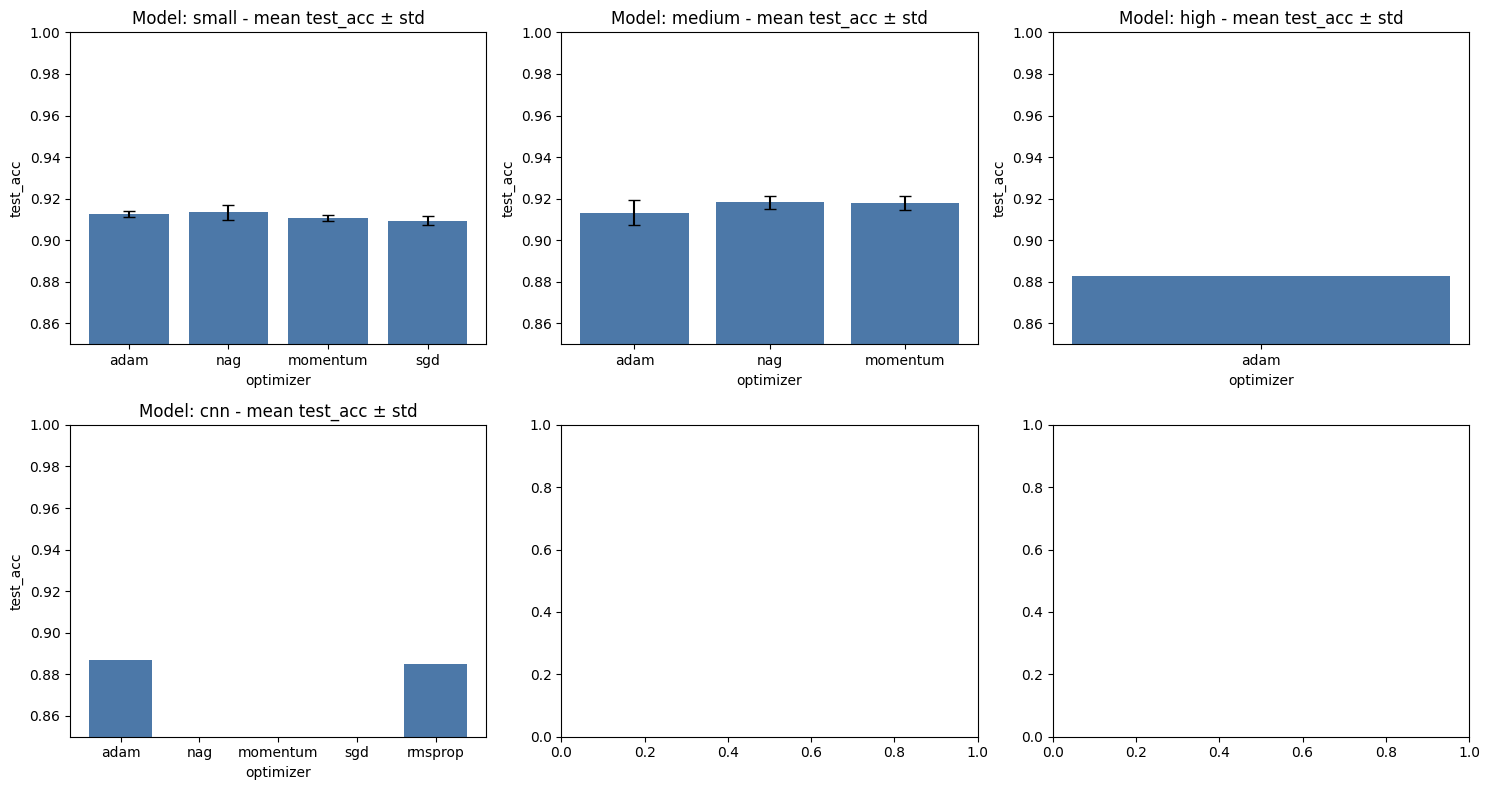

In [ ]:
if not df.empty:
    agg = (df
           .groupby(['model','optimizer'])
           .agg(mean_acc=('test_acc','mean'), std_acc=('test_acc','std'),
                best_acc=('test_acc','max'), n=('test_acc','size'))
           .reset_index())
    display(agg.sort_values(['model','mean_acc'], ascending=[True,False]))
    models = list(df['model'].dropna().unique())
    models = [m for m in models if m != 'nan']
    ncols = min(3, max(1, len(models)))
    nrows = int(math.ceil(len(models)/ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols,4*nrows), squeeze=False)
    for i, m in enumerate(models):
        ax = axes[i//ncols][i%ncols]
        sub = agg[agg['model']==m].sort_values('optimizer')
        ax.bar(sub['optimizer'].astype(str), sub['mean_acc'], yerr=sub['std_acc'], capsize=4, color='#4C78A8')
        ax.set_ylim(0.85, 1.0)
        ax.set_title(f'Model: {m} - mean test_acc +/- std')
        ax.set_ylabel('test_acc')
        ax.set_xlabel('optimizer')
    plt.tight_layout()
    plt.show()
else:
    print('No data.')

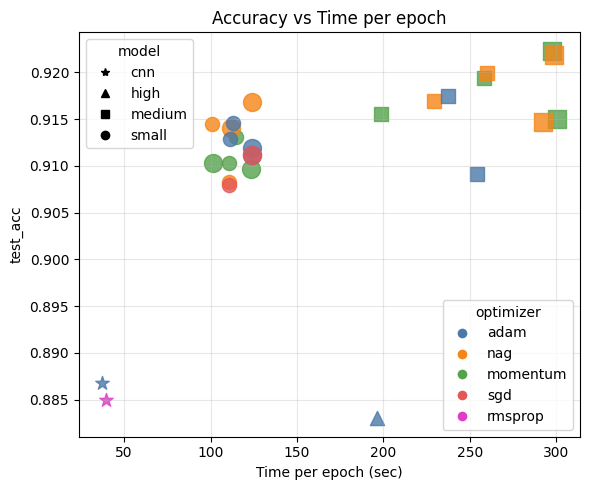

In [27]:
if not df.empty:
    colors = { 'adam':'#4C78A8', 'nag':'#F58518', 'momentum':'#54A24B', 'sgd':'#E45756', 'rmsprop':"#DE3EC6" }
    markers = { 'small':'o', 'medium':'s', 'high':'^', 'cnn':'*' }
    plt.figure(figsize=(6,5))
    for i, row in df.iterrows():
        c = colors.get(str(row['optimizer']), '#7A5195')
        m = markers.get(str(row['model']), 'o')
        plt.scatter(row['time_per_epoch'], row['test_acc'], c=c, marker=m, s=40 + 2*float(row.get('batch', 0)), alpha=0.8)
    plt.xlabel('Time per epoch (sec)')
    plt.ylabel('test_acc')
    plt.title('Accuracy vs Time per epoch')

    from matplotlib.lines import Line2D
    opt_legend = [Line2D([0],[0], marker='o', color='w', label=o, markerfacecolor=colors.get(o,'k'), markersize=8) for o in colors]
    model_legend = [Line2D([0],[0], marker=markers.get(m,'o'), color='k', linestyle='None', label=m) for m in sorted(df['model'].astype(str).unique())]
    leg1 = plt.legend(handles=opt_legend, title='optimizer', loc='lower right')
    plt.gca().add_artist(leg1)
    plt.legend(handles=model_legend, title='model', loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('No data.')

In [28]:
def summarize_findings(df):
    if df.empty:
        print('No data.')
        return
    print('Najbolji po test_acc')
    best = df.sort_values('test_acc', ascending=False).iloc[0]
    m = best['model']
    opt = best['optimizer']
    lr = best['lr']
    bs = int(best['batch']) if not pd.isna(best.get('batch', np.nan)) else None
    ta = best.get('test_acc', float('nan'))
    va = best.get('val_best_acc', float('nan'))
    f1 = best.get('test_macro_f1', float('nan'))
    print('Najbolji: model={}, optimizer={}, lr={}, batch={}, test_acc={:.4f}, val_best_acc={:.4f}, macro_f1={:.4f}'.format(m, opt, lr, bs, ta if not pd.isna(ta) else float('nan'), va if not pd.isna(va) else float('nan'), f1 if not pd.isna(f1) else float('nan')))

    print('Najbolji po optimizatoru (po prosecnoj test_acc)')
    opt_mean = (df.groupby('optimizer')['test_acc']
                 .agg(['mean','std','max','count'])
                 .sort_values('mean', ascending=False))
    display(opt_mean)

    print('Najbolji po modelu (test_acc)')
    for m, g in df.groupby('model', dropna=True):
        if g.empty or g['test_acc'].dropna().empty:
            print(f'{m}: nema validnih podataka')
            continue
        gb = g.sort_values('test_acc', ascending=False).iloc[0]
        bsv = int(gb['batch']) if not pd.isna(gb.get('batch', np.nan)) else None
        print(f"{m} : opt= {gb['optimizer']}, lr= {gb['lr']}, batch={bsv}, test_acc={gb['test_acc']:.4f}")

    print('Predlog batch_size po optimizatoru')
    for opt, g in df.groupby('optimizer', dropna=True):
        s = g.dropna(subset=['batch','test_acc'])
        if s.empty:
            print(f'{opt}: nema podataka za batch')
            continue
        b_perf = s.groupby('batch')['test_acc'].mean().sort_values(ascending=False)
        if b_perf.empty:
            print(f'{opt}: nema podataka za batch')
            continue
        top_b = int(b_perf.index[0])
        print(f"{opt}: najbolji batch={top_b} (prosecan test_acc={b_perf.iloc[0]:.4f})")

summarize_findings(df)

Najbolji po test_acc
Najbolji: model=medium, optimizer=momentum, lr=0.1, batch=64, test_acc=0.9223, val_best_acc=0.9243, macro_f1=0.9213
Najbolji po optimizatoru (po prosecnoj test_acc)


C:\Users\ninac\AppData\Local\Temp\ipykernel_15616\1232308289.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  opt_mean = (df.groupby('optimizer')['test_acc']


,mean,std,max,count
optimizer,,,,
nag,0.915863,0.004095,0.9218,8
momentum,0.914450,0.004573,0.9223,8
sgd,0.909500,0.002263,0.9111,2
adam,0.905875,0.013217,0.9175,8
rmsprop,0.885000,NaN,0.8850,1


Najbolji po modelu (test_acc)
cnn : opt= adam, lr= 0.001, batch=32, test_acc=0.8868
high : opt= adam, lr= 0.001, batch=32, test_acc=0.8830
medium : opt= momentum, lr= 0.1, batch=64, test_acc=0.9223
small : opt= nag, lr= 0.01, batch=64, test_acc=0.9168
Predlog batch_size po optimizatoru
adam: najbolji batch=64 (prosecan test_acc=0.9116)
nag: najbolji batch=64 (prosecan test_acc=0.9168)
momentum: najbolji batch=32 (prosecan test_acc=0.9146)
sgd: najbolji batch=64 (prosecan test_acc=0.9111)
rmsprop: najbolji batch=32 (prosecan test_acc=0.8850)


C:\Users\ninac\AppData\Local\Temp\ipykernel_15616\1232308289.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for opt, g in df.groupby('optimizer', dropna=True):
